In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
# ===== Step 1: Imports & load =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib   # to save scaler/model (optional)

sns.set(style="whitegrid")
%matplotlib inline

# Load
df = pd.read_csv('Mall_Customers.csv')
print("Dataset shape:", df.shape)
df.head(8)


Dataset shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94


In [ ]:
# Step 2: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("$","")
# common rename if present
df = df.rename(columns={
    'customerid':'customer_id',
    'annual_income_k':'annual_income_k',
    'spending_score_1-100':'spending_score'
})
# if the spending column still has original name, handle:
if 'spending_score_1-100' in df.columns:
    df = df.rename(columns={'spending_score_1-100':'spending_score'})

df.head()

,customer_id,genre,age,annual_income_k,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Step 3: Info & stats
print("Columns & dtypes:\n", df.dtypes, "\n")
print("Missing values per column:\n", df.isnull().sum(), "\n")
display(df.describe(include='all').T)

Columns & dtypes:
 customer_id         int64
genre              object
age                 int64
annual_income_k     int64
spending_score      int64
dtype: object 

Missing values per column:
 customer_id        0
genre              0
age                0
annual_income_k    0
spending_score     0
dtype: int64 



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
genre,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income_k,200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
spending_score,200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


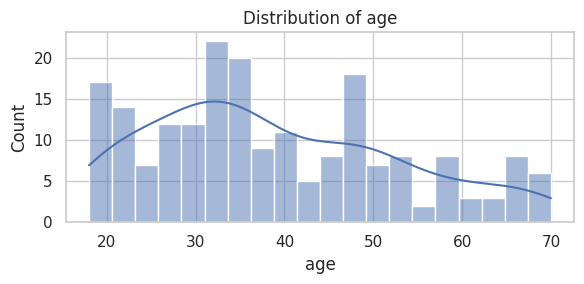

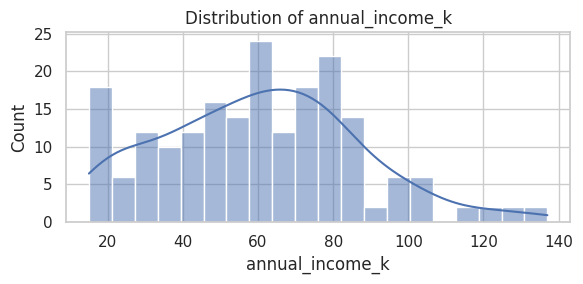

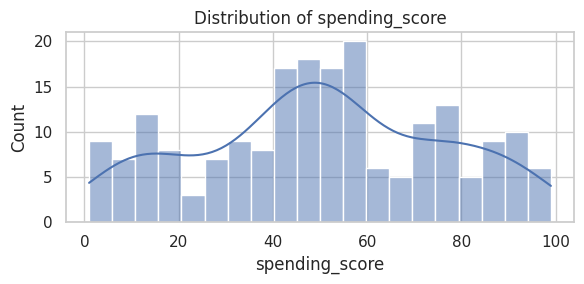

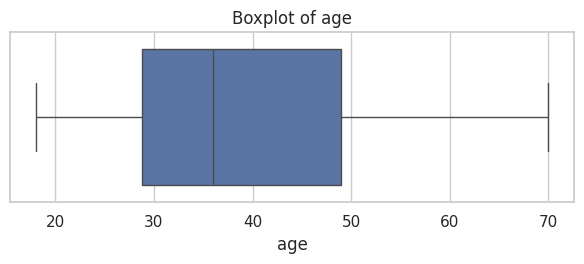

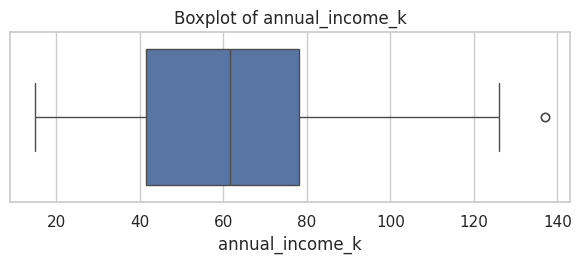

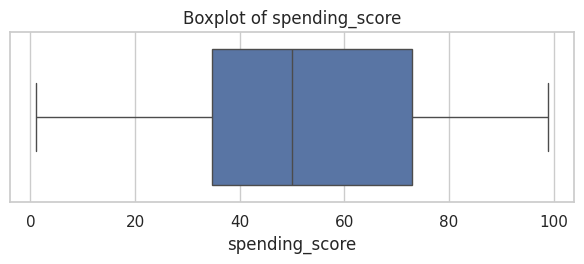

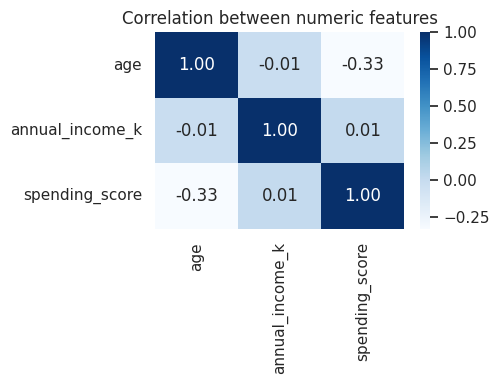

In [ ]:
# Step 4: Visual EDA

numeric_cols = ['age', 'annual_income_k', 'spending_score']

# Histograms + KDE
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Boxplots (outliers)
for col in numeric_cols:
    plt.figure(figsize=(6,2.8))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# Gender countplot
if 'gender' in df.columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x='gender', data=df)
    plt.title('Gender distribution')
    plt.tight_layout()
    plt.show()

# Correlation heatmap
plt.figure(figsize=(5,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Choose features (we use Age, Annual Income, Spending Score)
features = ['age', 'annual_income_k', 'spending_score']
X = df[features].copy()
X.shape

(200, 3)

In [ ]:
# ===== Step 6: Scaling =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler for later use (optional)
joblib.dump(scaler, 'scaler.joblib')

# Quick check: means ~0, std ~1
print("Scaled mean (per feature):", np.round(X_scaled.mean(axis=0), 4))
print("Scaled std  (per feature):", np.round(X_scaled.std(axis=0), 4))


Scaled mean (per feature): [-0. -0. -0.]
Scaled std  (per feature): [1. 1. 1.]


Explained variance ratio (PC1, PC2): [0.4427 0.3331]


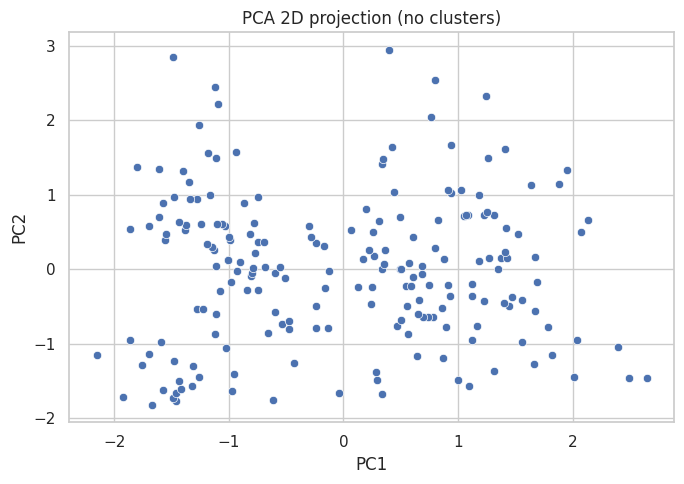

In [ ]:
# ===== Step 7: PCA (2D) for visualization =====
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 4))
# Save PCA (optional)
joblib.dump(pca, 'pca.joblib')

# Quick scatter (no clusters yet)
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])
plt.title('PCA 2D projection (no clusters)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.show()


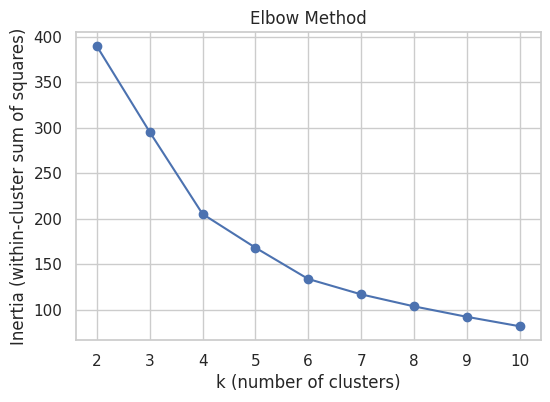

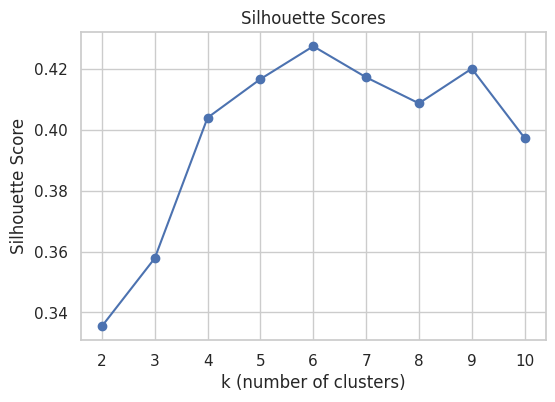

k=2  silhouette=0.3355
k=3  silhouette=0.3578
k=4  silhouette=0.4040
k=5  silhouette=0.4166
k=6  silhouette=0.4274
k=7  silhouette=0.4172
k=8  silhouette=0.4087
k=9  silhouette=0.4201
k=10  silhouette=0.3973


In [ ]:
# ===== Step 8: Elbow & Silhouette to pick K =====
inertia = []
sil_scores = []
K_range = range(2,11)
for k in K_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = kmeans_k.fit_predict(X_scaled)
    inertia.append(kmeans_k.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels_k))

# Plot elbow
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertia, '-o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# Plot silhouette
plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores, '-o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.grid(True)
plt.show()

# Print values for reference
for k, s in zip(K_range, sil_scores):
    print(f"k={k}  silhouette={s:.4f}")


In [ ]:
# ===== Step 9: Fit final model =====
# Auto-pick best K by silhouette (for demonstration). You may choose manually instead.
best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Suggested best_k (silhouette):", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach labels to original df
df['cluster'] = cluster_labels
print("Cluster counts:\n", df['cluster'].value_counts().sort_index())
# Save model
joblib.dump(kmeans, 'kmeans_model.joblib')


Suggested best_k (silhouette): 6
Cluster counts:
 cluster
0    33
1    45
2    24
3    39
4    38
5    21
Name: count, dtype: int64


['kmeans_model.joblib']

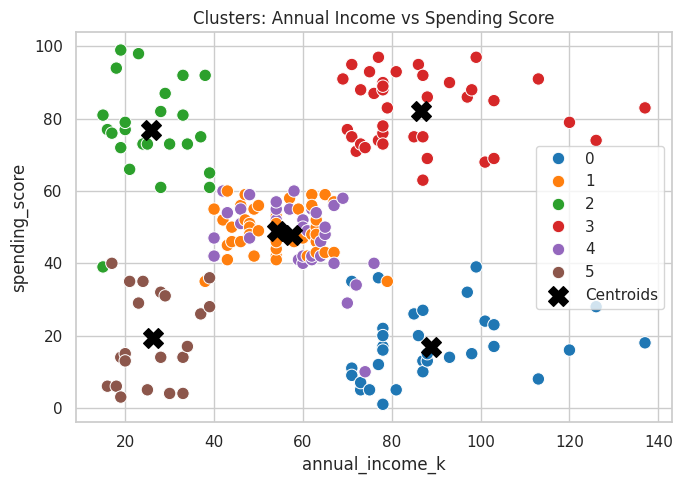

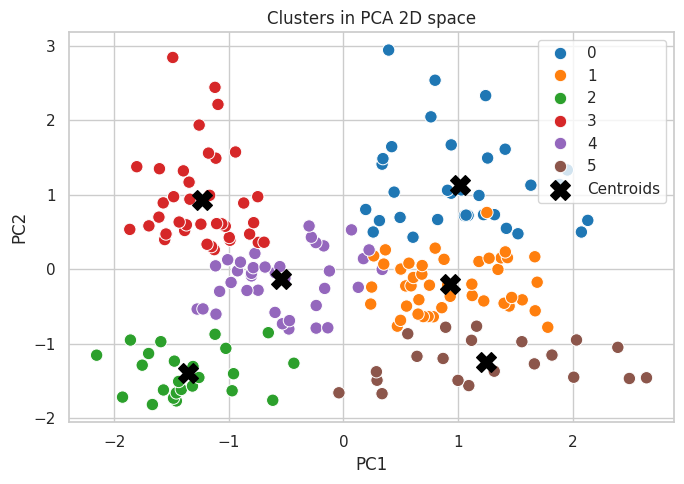

In [ ]:
# ===== Step 10: Visualize clusters =====
palette = sns.color_palette("tab10", n_colors=best_k)

# A) Annual Income vs Spending Score (business-friendly plot)
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='annual_income_k', y='spending_score',
    hue='cluster', data=df, palette=palette, s=80
)
centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=features)
# plot centroids (Income vs Spending)
plt.scatter(centers_df['annual_income_k'], centers_df['spending_score'],
            c='black', s=200, marker='X', label='Centroids')
plt.title('Clusters: Annual Income vs Spending Score')
plt.legend()
plt.tight_layout()
plt.show()

# B) PCA 2D scatter (clusters)
X_pca = pca.transform(X_scaled)   # already computed, but safe
plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['cluster'], palette=palette, s=80)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c='black', s=200, marker='X', label='Centroids')
plt.title('Clusters in PCA 2D space')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ===== Step 11: Profiling clusters =====
# Centroids in original scale (for interpretability)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids_orig, columns=features)
centroids_df['cluster'] = range(len(centroids_df))
display(centroids_df.round(2))

# Aggregate stats per cluster
profile = df.groupby('cluster')[features].agg(['count','mean','median','std']).round(2)
display(profile)

# Percentage distribution
pct = df['cluster'].value_counts(normalize=True).sort_index() * 100
print("Cluster percentages (%):\n", pct.round(2))


,age,annual_income_k,spending_score,cluster
0,41.94,88.94,16.97,0
1,56.33,54.27,49.07,1
2,25.25,25.83,76.92,2
3,32.69,86.54,82.13,3
4,26.68,57.58,47.79,4
5,45.52,26.29,19.38,5


age                      annual_income_k                       \
        count   mean median    std           count   mean median    std   
cluster                                                                   
0          33  41.94   43.0  10.18              33  88.94   86.0  16.59   
1          45  56.33   54.0   8.45              45  54.27   54.0   8.98   
2          24  25.25   23.5   5.33              24  25.83   24.5   8.06   
3          39  32.69   32.0   3.73              39  86.54   79.0  16.31   
4          38  26.68   26.0   7.12              38  57.58   60.0   9.85   
5          21  45.52   46.0  11.77              21  26.29   25.0   7.44   

        spending_score                       
                 count   mean median    std  
cluster                                      
0                   33  16.97   16.0   9.96  
1                   45  49.07   49.0   6.30  
2                   24  76.92   76.5  13.42  
3                   39  82.13   83.0   9.36  
4                   38  47.79   49.5   9.87  
5                   21  19.38   15.0  12.56

Cluster percentages (%):
 cluster
0    16.5
1    22.5
2    12.0
3    19.5
4    19.0
5    10.5
Name: proportion, dtype: float64


In [ ]:
# ===== Step 12: Human-friendly labels (example) =====
# Example labeling logic (adjust based on centroid values)
# We'll label clusters by a quick rule—interpret manually for final report.
centroids_df_sorted = centroids_df.sort_values(by='annual_income_k')
centroids_df_sorted
# Manually create mapping after inspection, e.g.:
label_map = {
    0: "Medium Income / Medium Spend",
    1: "Young High Spenders",
    2: "Low Income / Low Spend",
    3: "High Income / Low Spend"
}
# Only apply if labels count matches your k
if len(label_map) >= best_k:
    df['cluster_label'] = df['cluster'].map(label_map)
    df[['customer_id','age','annual_income_k','spending_score','cluster','cluster_label']].head()
else:
    print("Label map not applied automatically — please create a manual mapping based on centroids.")


Label map not applied automatically — please create a manual mapping based on centroids.


In [ ]:
# ===== Step 13: Save outputs =====
df.to_csv('mall_customers_with_clusters.csv', index=False)
centroids_df.to_csv('cluster_centroids.csv', index=False)
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca, 'pca.joblib')
joblib.dump(kmeans, 'kmeans_model.joblib')

# Download files (Colab)
from google.colab import files
files.download('mall_customers_with_clusters.csv')   # will prompt download
files.download('cluster_centroids.csv')
files.download('kmeans_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>